In [1]:
# ─── Environment Setup (do not edit) ────────────────────────────────────────
import os, sys
from pathlib import Path

def _detect_platform():
    try:
        import google.colab  # noqa: F401
        return "colab", False
    except ImportError:
        pass
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    if Path("/workspace").exists():
        return "vastai", True
    if sys.platform == "win32":
        return "windows", False
    if sys.platform == "darwin":
        return "mac", False
    return None, True

PLATFORM, _uncertain = _detect_platform()

if PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
else:
    PROJECT_ROOT = _nb_path.parents[1]

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

_env_map = {
    "colab":   PROJECT_ROOT / ".env.colab",
    "vastai":  PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac":     PROJECT_ROOT / ".env.mac",
}
_env_file = _env_map.get(PLATFORM, PROJECT_ROOT / ".env")

from dotenv import load_dotenv
if not _env_file.exists():
    _fallback = PROJECT_ROOT / ".env"
    _env_file = _fallback if _fallback.exists() else _env_file

load_dotenv(_env_file, override=True)

from utils.env_utils import get_data_root
DATA_ROOT = get_data_root()

print(f"✅ Platform : {PLATFORM or 'unknown'}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print(f"{'✅' if DATA_ROOT.exists() else '❌'} Path exists: {DATA_ROOT.exists()}")
# ─────────────────────────────────────────────────────────────────────────────

✅ Platform : mac
✅ DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
✅ Path exists: True


# Phân tích Dữ liệu Crawled — ViFactCheck (Crawled JSON Only)

Notebook này phân tích **dữ liệu thực tế đã crawl** từ 9 báo điện tử tiếng Việt,  
dựa hoàn toàn vào các file JSON trong `DATA_ROOT/data/json/` — không dùng HuggingFace.

**Fields phân tích:** `domain`, `title`, `text`, `text_length`, `paragraph_count`,  
`image_count`, `has_images`, `link_count`, `crawl_timestamp`, `source_url`  
**Splits:** train / dev / test (theo tên file JSON)

In [2]:
import json
import warnings
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

SPLIT_COLORS  = {"train": "#3498db", "dev": "#9b59b6", "test": "#e67e22"}
DOMAIN_COLORS = sns.color_palette("tab10", 9)

print("✅ Imports ready.")

✅ Imports ready.


## 1. Tải dữ liệu (từ JSON)

In [3]:
JSON_DIR = DATA_ROOT / "data" / "json"

records = []
for split in ["train", "dev", "test"]:
    path = JSON_DIR / f"news_data_vifactcheck_{split}_labeled.json"
    with open(path) as f:
        crawled = json.load(f)
    for rec in crawled:
        feat = rec["features"]
        meta = rec["metadata"]
        records.append({
            "id":              rec["id"],
            "split":           split,
            "source_url":      meta.get("source_url", ""),
            "domain":          feat.get("domain", ""),
            "title":           feat.get("title", ""),
            "text":            feat.get("text", ""),
            "text_length":     feat.get("text_length", 0),
            "paragraph_count": feat.get("paragraph_count", 0),
            "image_count":     feat.get("image_count", 0),
            "has_images":      feat.get("has_images", False),
            "link_count":      feat.get("link_count", 0),
            "crawl_success":   meta.get("success", False),
            "crawl_timestamp": meta.get("crawl_timestamp", ""),
            "language":        meta.get("language", ""),
            "num_images_media": len(rec.get("media", {}).get("images", [])),
        })

df = pd.DataFrame(records)
df["has_text"]  = df["text_length"] > 0
df["has_title"] = df["title"].str.strip().str.len() > 0
df["title_length"] = df["title"].str.strip().str.len()

print(f"✅ Loaded {len(df):,} records  |  splits: {dict(df['split'].value_counts().reindex(['train','dev','test']))}")
print(f"   Columns: {list(df.columns)}")
df.head(3)

✅ Loaded 7,232 records  |  splits: {'train': np.int64(5062), 'dev': np.int64(723), 'test': np.int64(1447)}
   Columns: ['id', 'split', 'source_url', 'domain', 'title', 'text', 'text_length', 'paragraph_count', 'image_count', 'has_images', 'link_count', 'crawl_success', 'crawl_timestamp', 'language', 'num_images_media', 'has_text', 'has_title', 'title_length']


,id,split,source_url,domain,title,text,text_length,paragraph_count,image_count,has_images,link_count,crawl_success,crawl_timestamp,language,num_images_media,has_text,has_title,title_length
0,89d215119ab8eca5,train,https://plo.vn/9-quan-huyen-o-tphcm-se-bi-cup-...,plo.vn,,,0,0,0,False,81,True,2026-06-07T17:33:54.039716,vi,0,False,False,0
1,c7ce67dc4be841df,train,https://nld.com.vn/giao-duc-khoa-hoc/hanh-trin...,nld.com.vn,,,0,0,0,False,0,True,2026-06-07T17:33:56.084256,vi,0,False,False,0
2,b1233e8ace66c810,train,https://baotintuc.vn/an-ninh-trat-tu/bat-tam-g...,baotintuc.vn,,,0,0,2,True,0,True,2026-06-07T17:33:56.674088,vi,2,False,False,0


## 2. Tổng quan dữ liệu crawled

In [4]:
rows = []
for grp in ["train", "dev", "test", "ALL"]:
    sub = df if grp == "ALL" else df[df.split == grp]
    rows.append({
        "Split": grp,
        "Tổng bài": f"{len(sub):,}",
        "Có text (%)": f"{sub.has_text.mean()*100:.1f}%",
        "Có tiêu đề (%)": f"{sub.has_title.mean()*100:.1f}%",
        "Có hình ảnh (%)": f"{sub.has_images.mean()*100:.1f}%",
        "Avg text len": f"{sub.text_length[sub.has_text].mean():.0f}" if sub.has_text.any() else "—",
        "Avg ảnh/bài": f"{sub.image_count.mean():.2f}",
        "Avg links/bài": f"{sub.link_count.mean():.1f}",
        "Crawl OK (%)": f"{sub.crawl_success.mean()*100:.1f}%",
    })

overview = pd.DataFrame(rows).set_index("Split")
display(overview.style.set_caption("Bảng 1: Tổng quan dữ liệu crawled theo split"))

,Tổng bài,Có text (%),Có tiêu đề (%),Có hình ảnh (%),Avg text len,Avg ảnh/bài,Avg links/bài,Crawl OK (%)
Split,,,,,,,,
train,"5,062",44.9%,54.2%,65.6%,2972,1.37,9.8,100.0%
dev,723,45.6%,53.0%,65.4%,2917,1.24,9.6,100.0%
test,"1,447",44.5%,54.7%,67.2%,3095,1.45,9.3,100.0%
ALL,"7,232",44.9%,54.2%,65.9%,2991,1.38,9.7,100.0%


## 3. Dữ liệu mẫu (từ JSON)

In [5]:
sample_cols = ["split", "domain", "title", "text_length", "paragraph_count",
               "image_count", "link_count", "has_images"]

# 1 mẫu có text + 1 mẫu không có text mỗi split
sample_rows = []
for split in ["train", "dev", "test"]:
    sub = df[df.split == split]
    for has_t in [True, False]:
        row = sub[sub.has_text == has_t]
        if len(row):
            sample_rows.append(row.iloc[0][sample_cols])

sample_df = pd.DataFrame(sample_rows).reset_index(drop=True)
sample_df["title"] = sample_df["title"].str[:55].where(sample_df["title"].str.len() > 0, "(không có tiêu đề)")

display(
    sample_df.style
    .set_caption("Bảng 2: Dữ liệu mẫu (có text / không có text)")
    .set_properties(**{"text-align": "left"})
)

,split,domain,title,text_length,paragraph_count,image_count,link_count,has_images
0,train,baochinhphu.vn,Lan toả những giá trị văn hóa tốt đẹp 'chân - thiện - m,6983,25,5,0,True
1,train,plo.vn,(không có tiêu đề),0,0,0,81,False
2,dev,baochinhphu.vn,"Phát huy giá trị báo, tạp chí của Đảng trong thời đại b",8166,26,4,0,True
3,dev,nld.com.vn,(không có tiêu đề),0,0,0,1,False
4,test,vnexpress.net,Quán bánh cuốn trong ngõ nhỏ 'rẻ nhất Hà Nội',4245,16,2,0,True
5,test,plo.vn,(không có tiêu đề),0,0,0,77,False


## 4. Phân bố theo split

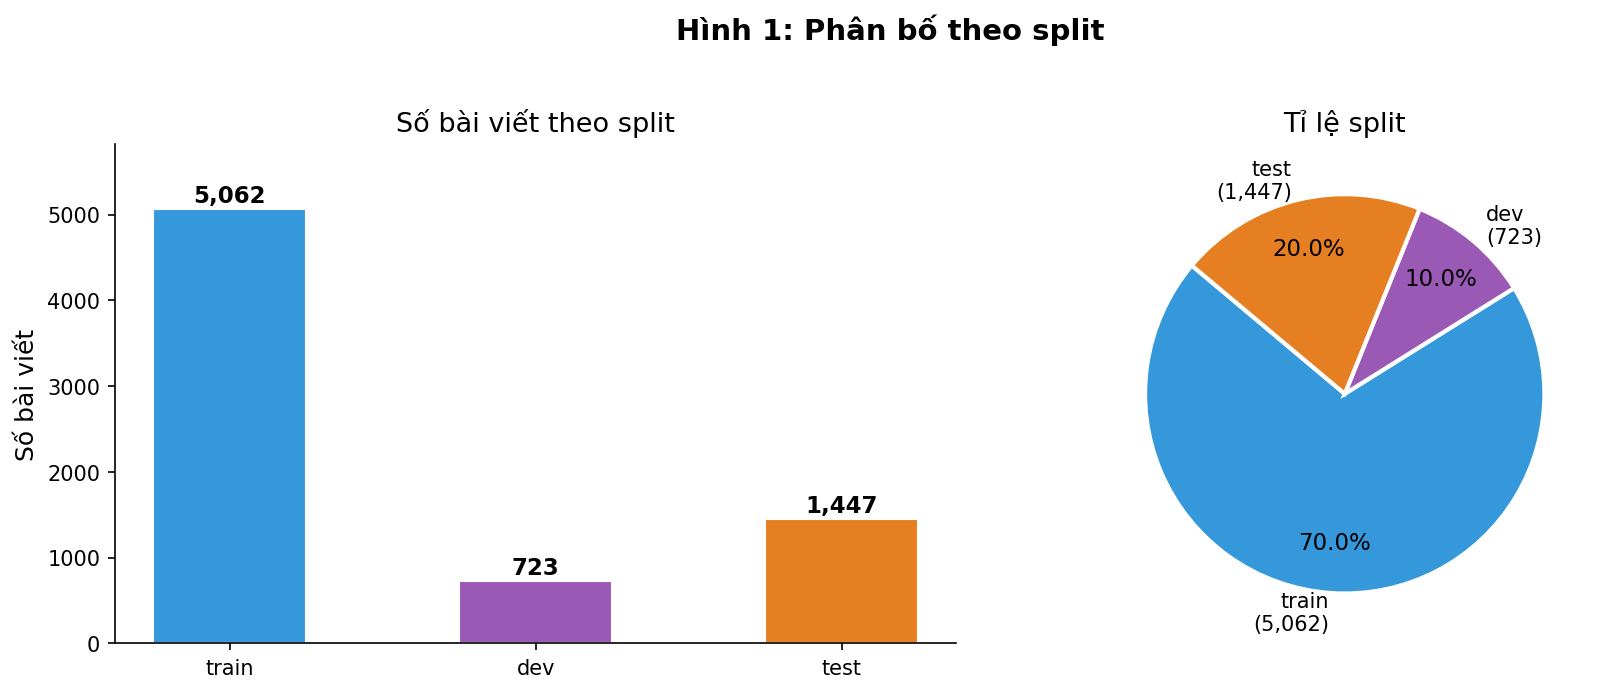

Saved: fig_c1_split.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

split_counts = df["split"].value_counts().reindex(["train", "dev", "test"])
colors = [SPLIT_COLORS[s] for s in split_counts.index]

bars = axes[0].bar(split_counts.index, split_counts.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, split_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Số bài viết theo split")
axes[0].set_ylabel("Số bài viết")
axes[0].set_ylim(0, split_counts.max() * 1.15)

axes[1].pie(split_counts.values,
            labels=[f"{s}\n({v:,})" for s, v in zip(split_counts.index, split_counts.values)],
            colors=colors, autopct="%1.1f%%", startangle=140, pctdistance=0.75,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Tỉ lệ split")

plt.suptitle("Hình 1: Phân bố theo split", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_c1_split.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c1_split.png")

## 5. Phân bố theo nguồn tin (Domain)

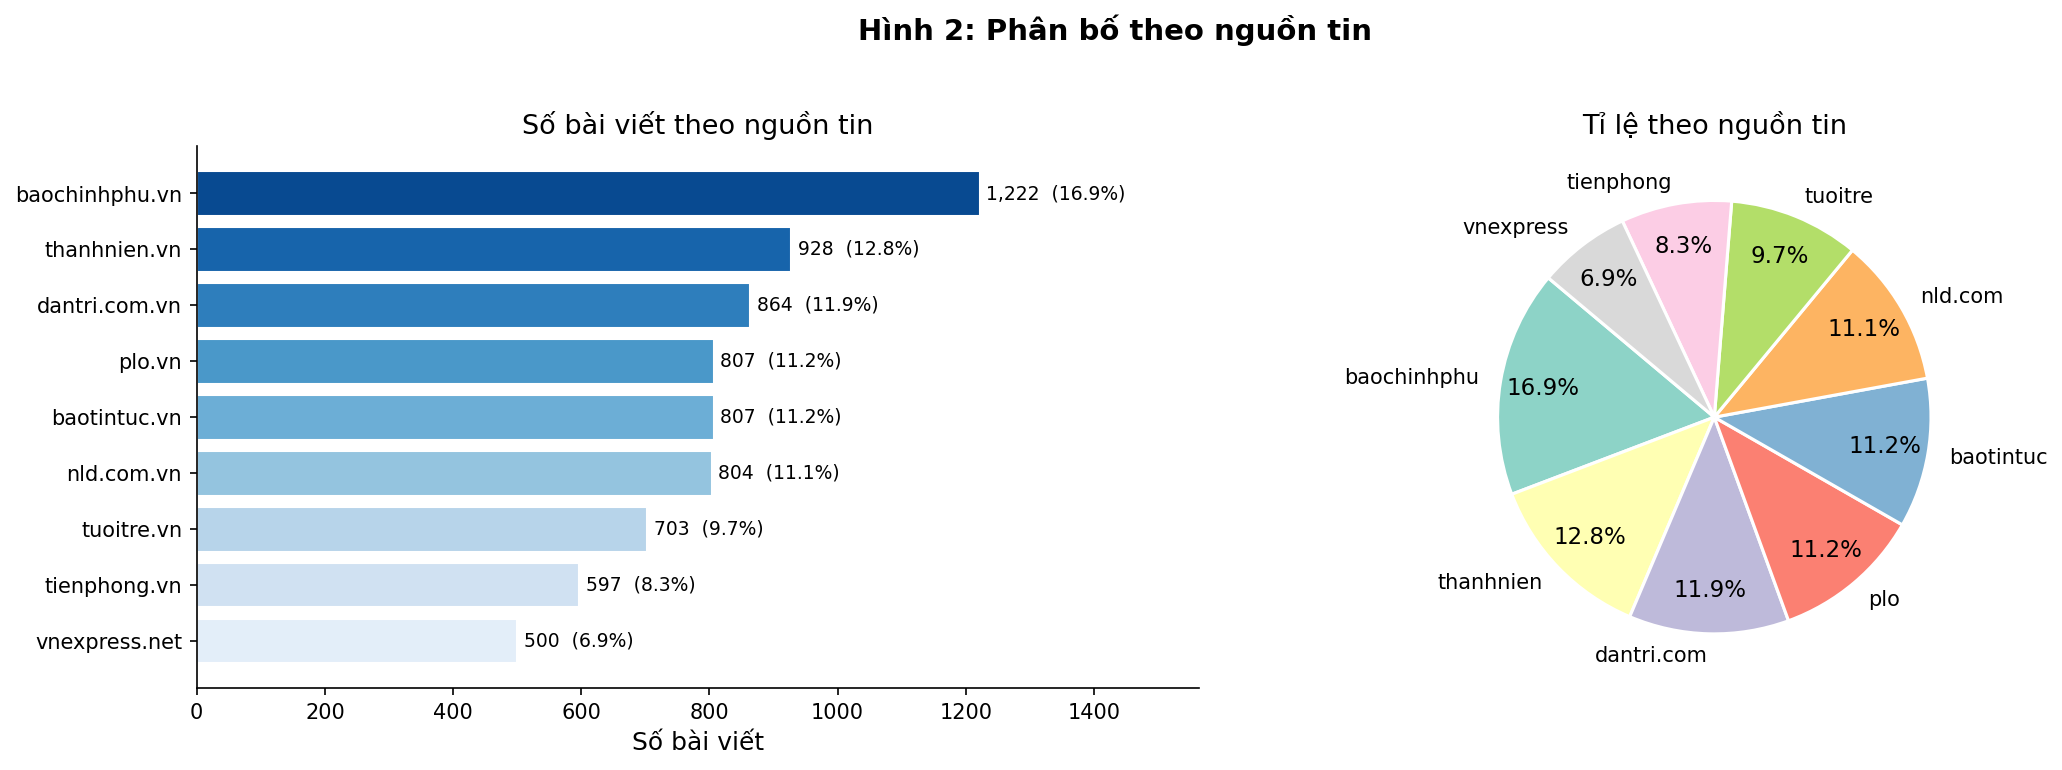

Saved: fig_c2_domain.png


In [7]:
domain_counts = df["domain"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette = sns.color_palette("Blues_r", len(domain_counts))
axes[0].barh(domain_counts.index[::-1], domain_counts.values[::-1],
             color=palette[::-1], edgecolor="white")
for i, (idx, val) in enumerate(zip(domain_counts.index[::-1], domain_counts.values[::-1])):
    axes[0].text(val + 10, i, f"{val:,}  ({val/len(df)*100:.1f}%)", va="center", fontsize=9)
axes[0].set_title("Số bài viết theo nguồn tin")
axes[0].set_xlabel("Số bài viết")
axes[0].set_xlim(0, domain_counts.max() * 1.28)

axes[1].pie(domain_counts.values,
            labels=[d.replace(".vn","").replace(".net","") for d in domain_counts.index],
            autopct="%1.1f%%", startangle=140, pctdistance=0.80,
            wedgeprops=dict(edgecolor="white", linewidth=1.5),
            colors=sns.color_palette("Set3", len(domain_counts)))
axes[1].set_title("Tỉ lệ theo nguồn tin")

plt.suptitle("Hình 2: Phân bố theo nguồn tin", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_c2_domain.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c2_domain.png")

## 6. Chất lượng thu thập theo nguồn tin

Mỗi nguồn tin có thể chặn bot, dùng JavaScript rendering, hoặc paywall —  
dẫn đến tỉ lệ extract thành công khác nhau cho từng loại dữ liệu.

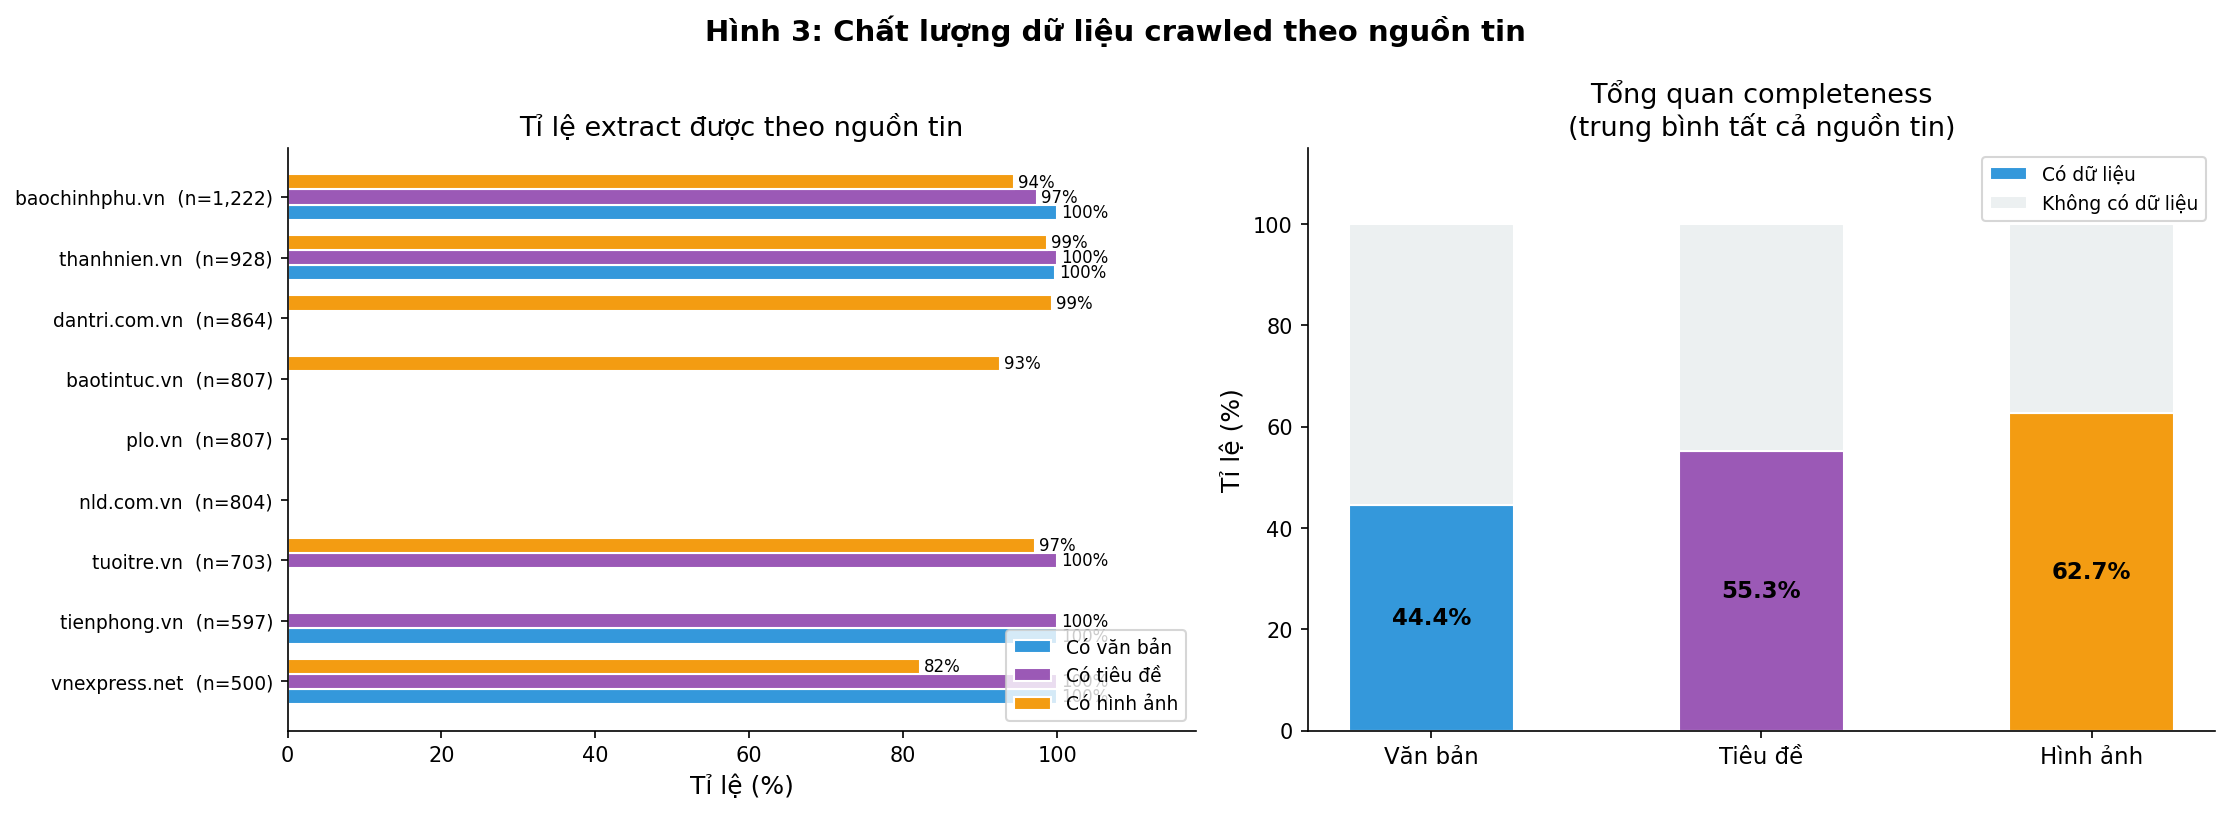

Saved: fig_c3_crawl_quality.png


,Tổng,Text (%),Title (%),Ảnh (%),Avg text len,Avg ảnh,Avg links
Nguồn tin,,,,,,,
baochinhphu.vn,1222,100.000000,97.400000,94.400000,3635.500000,1.900000,0.000000
thanhnien.vn,928,99.800000,100.000000,98.700000,2528.600000,2.400000,3.000000
dantri.com.vn,864,0.000000,0.000000,99.300000,0.000000,2.600000,0.000000
baotintuc.vn,807,0.000000,0.000000,92.600000,0.000000,1.600000,0.000000
plo.vn,807,0.000000,0.000000,0.000000,0.000000,0.000000,79.800000
nld.com.vn,804,0.000000,0.000000,0.000000,0.000000,0.000000,0.700000
tuoitre.vn,703,0.000000,100.000000,97.200000,0.000000,1.800000,1.700000
tienphong.vn,597,100.000000,100.000000,0.000000,2555.100000,0.000000,1.000000
vnexpress.net,500,100.000000,100.000000,82.200000,2782.300000,1.300000,0.800000


In [8]:
dq = (
    df.groupby("domain")
    .agg(
        total      =("id",         "count"),
        pct_text   =("has_text",   "mean"),
        pct_title  =("has_title",  "mean"),
        pct_images =("has_images", "mean"),
        avg_text   =("text_length","mean"),
        avg_imgs   =("image_count","mean"),
        avg_links  =("link_count", "mean"),
    )
    .reset_index()
)
dq[["pct_text","pct_title","pct_images"]] *= 100
dq = dq.sort_values("total", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: grouped bar (% per field per domain)
domains = dq["domain"].tolist()
y = np.arange(len(domains))
h = 0.25

axes[0].barh(y + h,  dq["pct_text"],   h, label="Có văn bản",  color="#3498db", edgecolor="white")
axes[0].barh(y,      dq["pct_title"],  h, label="Có tiêu đề",  color="#9b59b6", edgecolor="white")
axes[0].barh(y - h,  dq["pct_images"], h, label="Có hình ảnh", color="#f39c12", edgecolor="white")

for bars_data, offset in [(dq["pct_text"], h), (dq["pct_title"], 0), (dq["pct_images"], -h)]:
    for i, v in enumerate(bars_data):
        if v > 1:
            axes[0].text(v + 0.5, y[i] + offset, f"{v:.0f}%", va="center", fontsize=8)

axes[0].set_yticks(y)
axes[0].set_yticklabels(
    [f"{d}  (n={int(dq.loc[i,'total']):,})" for i, d in enumerate(domains)], fontsize=9
)
axes[0].set_xlim(0, 118)
axes[0].set_xlabel("Tỉ lệ (%)")
axes[0].set_title("Tỉ lệ extract được theo nguồn tin")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].invert_yaxis()

# Right: stacked completeness overview
categories = ["Văn bản", "Tiêu đề", "Hình ảnh"]
vals_yes   = [dq["pct_text"].mean(), dq["pct_title"].mean(), dq["pct_images"].mean()]
vals_no    = [100 - v for v in vals_yes]
x = np.arange(len(categories))
axes[1].bar(x, vals_yes, color=["#3498db","#9b59b6","#f39c12"], edgecolor="white", width=0.5,
            label="Có dữ liệu")
axes[1].bar(x, vals_no, bottom=vals_yes, color="#ecf0f1", edgecolor="white", width=0.5,
            label="Không có dữ liệu")
for xi, v in zip(x, vals_yes):
    axes[1].text(xi, v/2, f"{v:.1f}%", ha="center", va="center", fontweight="bold", fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, fontsize=11)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel("Tỉ lệ (%)")
axes[1].set_title("Tổng quan completeness\n(trung bình tất cả nguồn tin)")
axes[1].legend(fontsize=9)

plt.suptitle("Hình 3: Chất lượng dữ liệu crawled theo nguồn tin", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_c3_crawl_quality.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c3_crawl_quality.png")

# Table
display(
    dq.rename(columns={
        "domain":"Nguồn tin","total":"Tổng","pct_text":"Text (%)","pct_title":"Title (%)",
        "pct_images":"Ảnh (%)","avg_text":"Avg text len","avg_imgs":"Avg ảnh","avg_links":"Avg links"
    }).round(1).set_index("Nguồn tin")
    .style.background_gradient(subset=["Text (%)","Title (%)","Ảnh (%)"], cmap="RdYlGn", vmin=0, vmax=100)
    .set_caption("Bảng 3: Chất lượng thu thập theo nguồn tin")
)

## 7. Thống kê văn bản (Text Statistics)

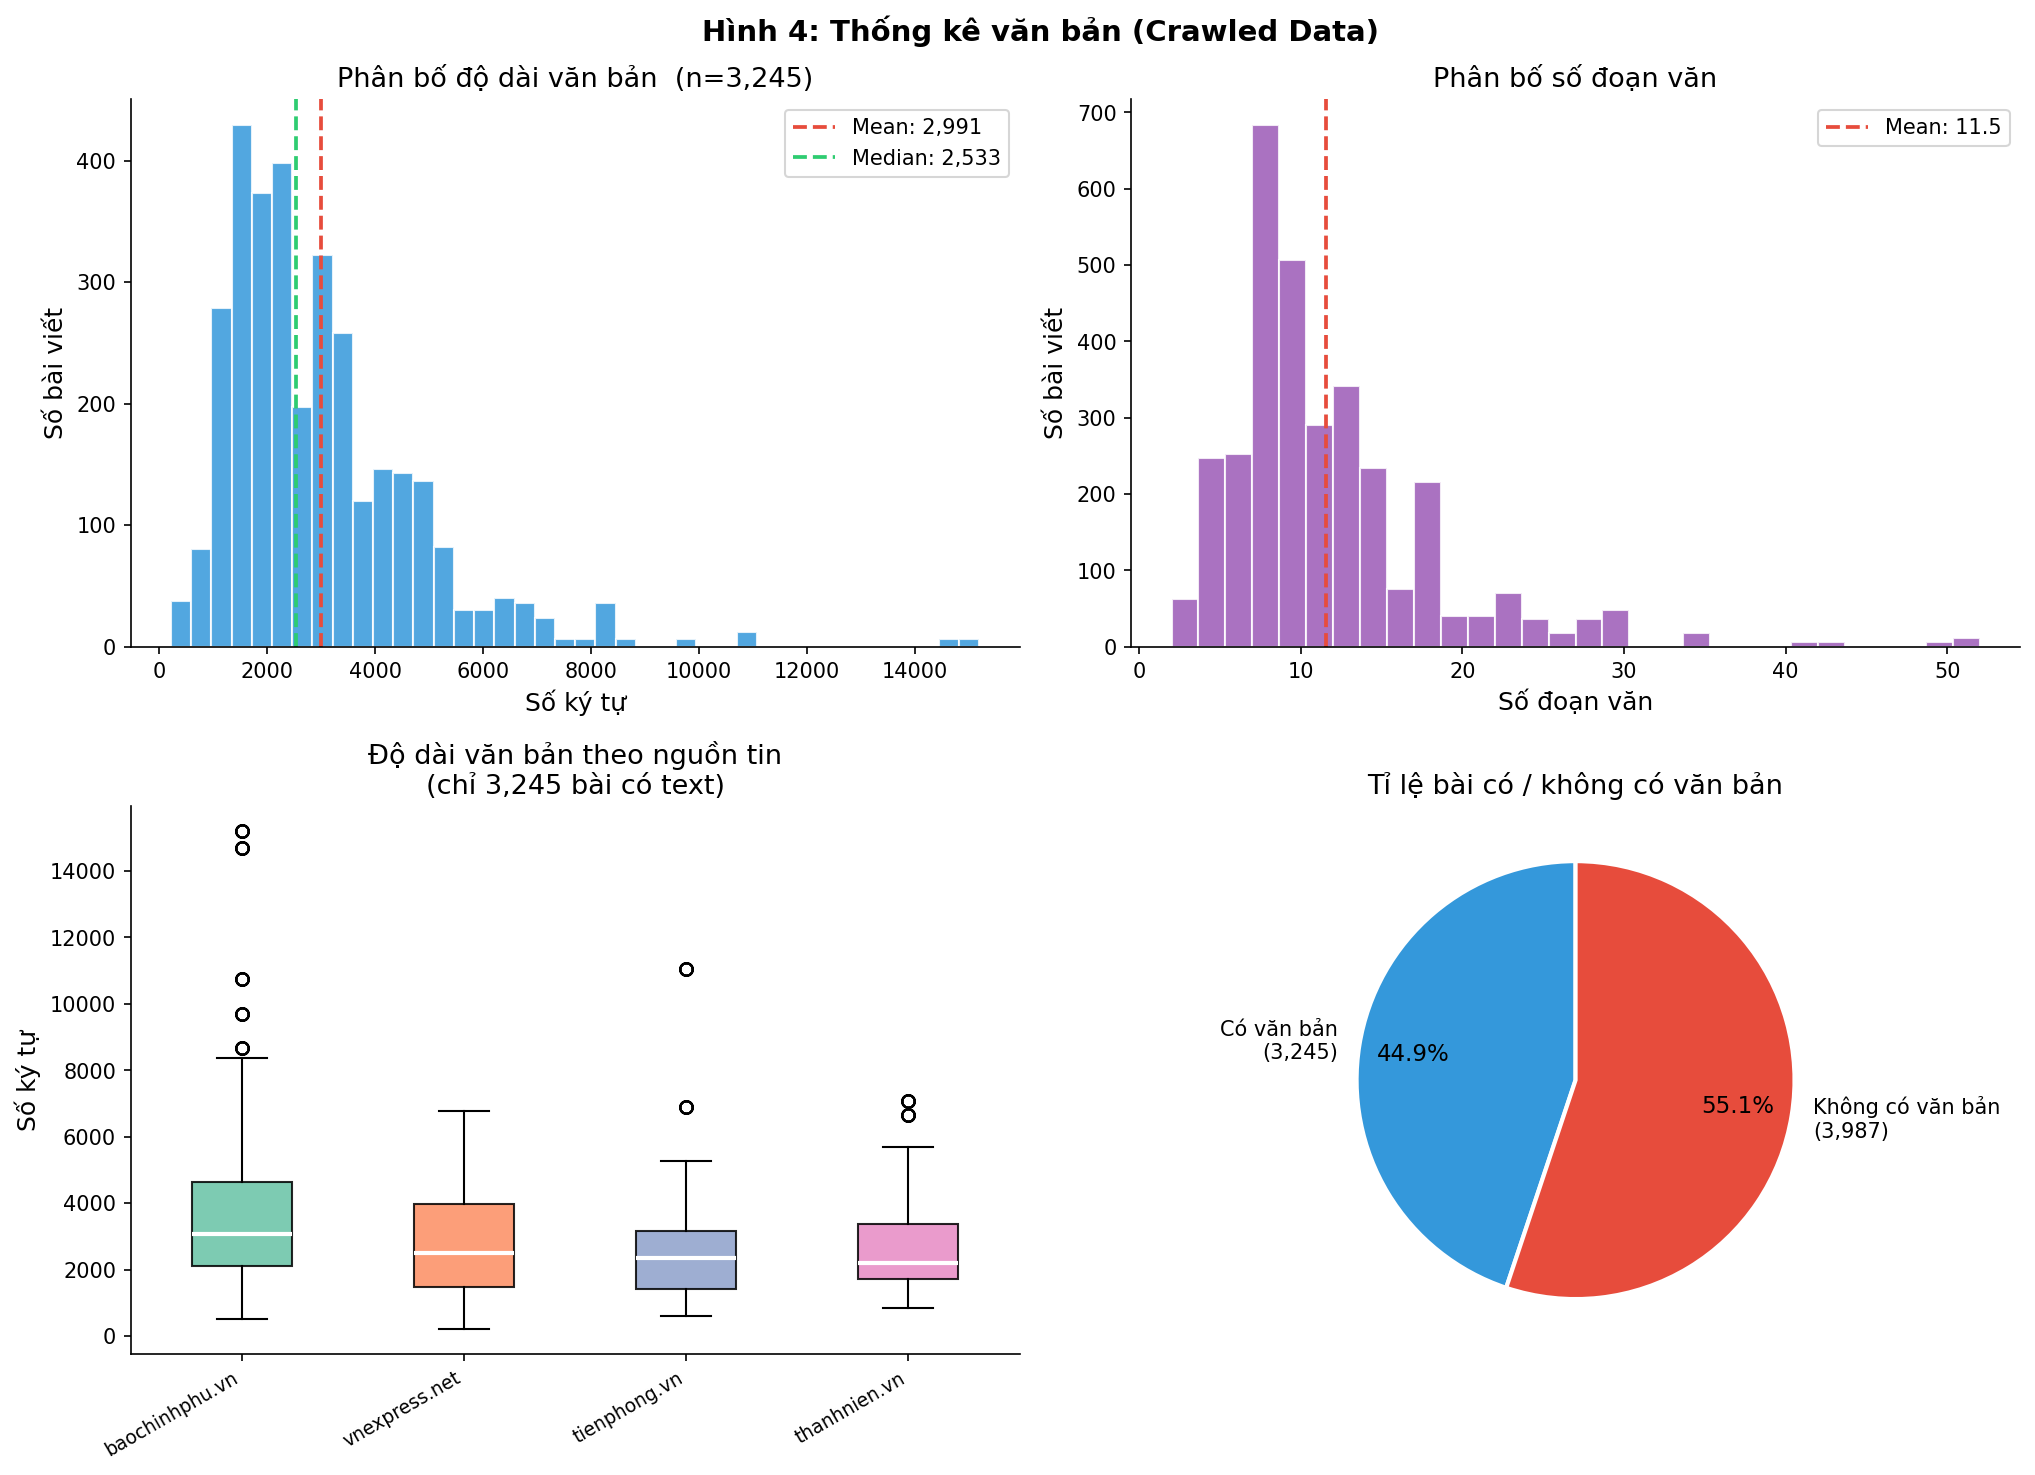

Saved: fig_c4_text_stats.png

count     3245.0
mean      2991.0
std       1827.2
min        215.0
25%       1698.0
50%       2533.0
75%       3798.0
max      15197.0
Name: text_length, dtype: float64


In [9]:
df_text = df[df.has_text].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7a: text_length histogram
axes[0,0].hist(df_text["text_length"], bins=40, color="#3498db", edgecolor="white", alpha=0.85)
axes[0,0].axvline(df_text.text_length.mean(),   color="#e74c3c", ls="--", lw=1.8,
                  label=f"Mean: {df_text.text_length.mean():,.0f}")
axes[0,0].axvline(df_text.text_length.median(), color="#2ecc71", ls="--", lw=1.8,
                  label=f"Median: {df_text.text_length.median():,.0f}")
axes[0,0].set_title(f"Phân bố độ dài văn bản  (n={len(df_text):,})")
axes[0,0].set_xlabel("Số ký tự")
axes[0,0].set_ylabel("Số bài viết")
axes[0,0].legend()

# 7b: paragraph count histogram
axes[0,1].hist(df_text["paragraph_count"], bins=30, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[0,1].axvline(df_text.paragraph_count.mean(), color="#e74c3c", ls="--", lw=1.8,
                  label=f"Mean: {df_text.paragraph_count.mean():.1f}")
axes[0,1].set_title("Phân bố số đoạn văn")
axes[0,1].set_xlabel("Số đoạn văn")
axes[0,1].set_ylabel("Số bài viết")
axes[0,1].legend()

# 7c: text_length by domain (boxplot — only domains with text)
dom_order = df_text.groupby("domain")["text_length"].median().sort_values(ascending=False).index.tolist()
data_box  = [df_text[df_text.domain == d]["text_length"].values for d in dom_order]
bp = axes[1,0].boxplot(data_box, patch_artist=True,
                        medianprops=dict(color="white", linewidth=2))
palette = sns.color_palette("Set2", len(dom_order))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[1,0].set_xticks(range(1, len(dom_order)+1))
axes[1,0].set_xticklabels(dom_order, rotation=30, ha="right", fontsize=9)
axes[1,0].set_title(f"Độ dài văn bản theo nguồn tin\n(chỉ {len(df_text):,} bài có text)")
axes[1,0].set_ylabel("Số ký tự")

# 7d: text completeness pie
has_n  = df.has_text.sum()
no_n   = (~df.has_text).sum()
axes[1,1].pie([has_n, no_n],
              labels=[f"Có văn bản\n({has_n:,})", f"Không có văn bản\n({no_n:,})"],
              colors=["#3498db","#e74c3c"], autopct="%1.1f%%", startangle=90,
              wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.75)
axes[1,1].set_title("Tỉ lệ bài có / không có văn bản")

plt.suptitle("Hình 4: Thống kê văn bản (Crawled Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_c4_text_stats.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c4_text_stats.png")
print()
print(df_text["text_length"].describe().round(1))

## 8. Độ dài văn bản theo nguồn tin

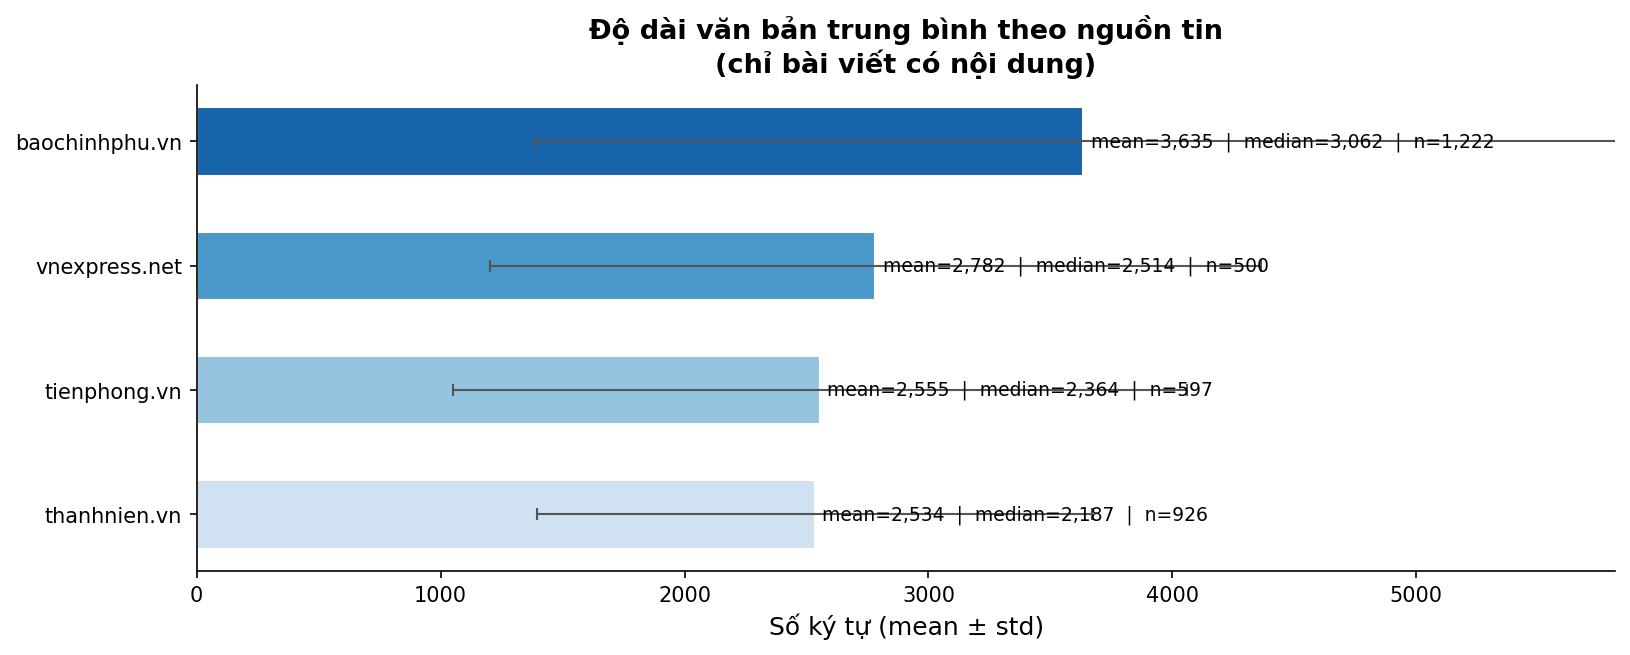

Saved: fig_c5_text_by_domain.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))

avg_len = (
    df_text.groupby("domain")["text_length"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=True)
)
palette = sns.color_palette("Blues", len(avg_len))
bars = ax.barh(avg_len.index, avg_len["mean"], color=palette, edgecolor="white", height=0.55)
ax.errorbar(
    avg_len["mean"], range(len(avg_len)),
    xerr=df_text.groupby("domain")["text_length"].std().reindex(avg_len.index).values,
    fmt="none", color="#555", lw=1, capsize=3
)
for i, (idx, row) in enumerate(avg_len.iterrows()):
    ax.text(row["mean"] + 30, i,
            f"mean={row['mean']:,.0f}  |  median={row['median']:,.0f}  |  n={int(row['count']):,}",
            va="center", fontsize=9)

ax.set_xlabel("Số ký tự (mean ± std)")
ax.set_xlim(0, avg_len["mean"].max() * 1.6)
ax.set_title("Độ dài văn bản trung bình theo nguồn tin\n(chỉ bài viết có nội dung)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_c5_text_by_domain.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c5_text_by_domain.png")

## 9. Thống kê tiêu đề (Title)

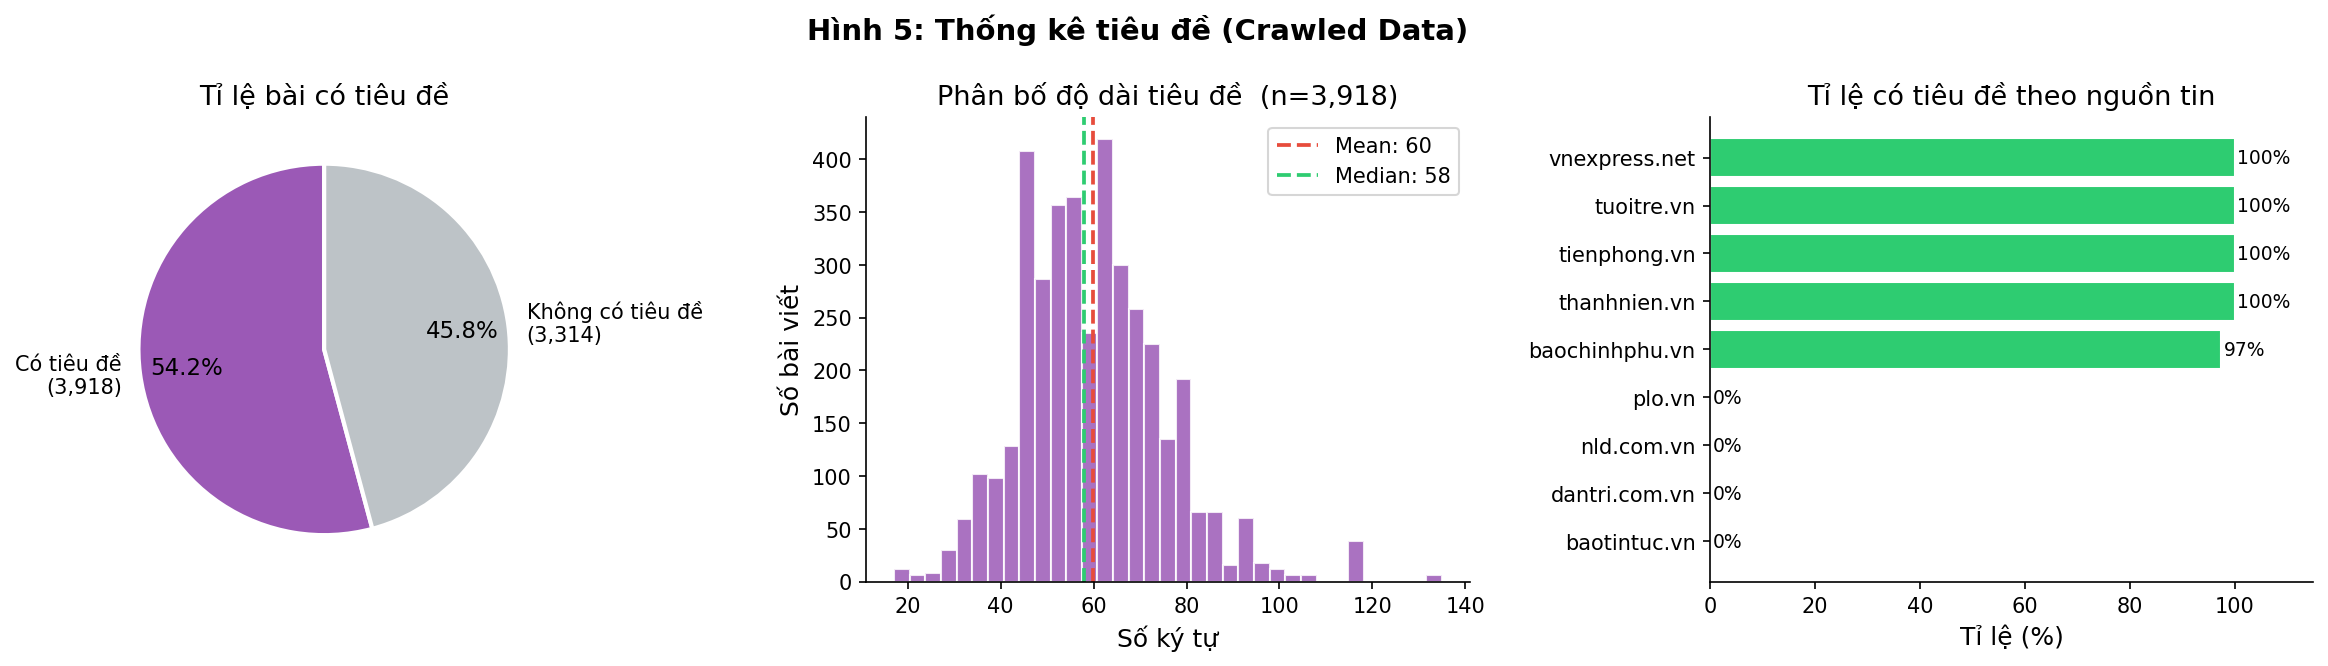

Saved: fig_c6_title.png


In [11]:
df_titled = df[df.has_title]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Pie completeness
has_t, no_t = df.has_title.sum(), (~df.has_title).sum()
axes[0].pie([has_t, no_t],
            labels=[f"Có tiêu đề\n({has_t:,})", f"Không có tiêu đề\n({no_t:,})"],
            colors=["#9b59b6","#bdc3c7"], autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.75)
axes[0].set_title("Tỉ lệ bài có tiêu đề")

# Title length histogram
axes[1].hist(df_titled.title_length, bins=35, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[1].axvline(df_titled.title_length.mean(),   color="#e74c3c", ls="--", lw=1.8,
                label=f"Mean: {df_titled.title_length.mean():.0f}")
axes[1].axvline(df_titled.title_length.median(), color="#2ecc71", ls="--", lw=1.8,
                label=f"Median: {df_titled.title_length.median():.0f}")
axes[1].set_title(f"Phân bố độ dài tiêu đề  (n={len(df_titled):,})")
axes[1].set_xlabel("Số ký tự")
axes[1].set_ylabel("Số bài viết")
axes[1].legend()

# Title completeness per domain
title_pct = df.groupby("domain")["has_title"].mean().mul(100).sort_values(ascending=True)
colors_t  = ["#e74c3c" if v < 50 else "#2ecc71" for v in title_pct.values]
axes[2].barh(title_pct.index, title_pct.values, color=colors_t, edgecolor="white")
for i, (d, v) in enumerate(zip(title_pct.index, title_pct.values)):
    axes[2].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
axes[2].set_title("Tỉ lệ có tiêu đề theo nguồn tin")
axes[2].set_xlabel("Tỉ lệ (%)")
axes[2].set_xlim(0, 115)

plt.suptitle("Hình 5: Thống kê tiêu đề (Crawled Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_c6_title.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c6_title.png")

## 10. Thống kê hình ảnh (Media)

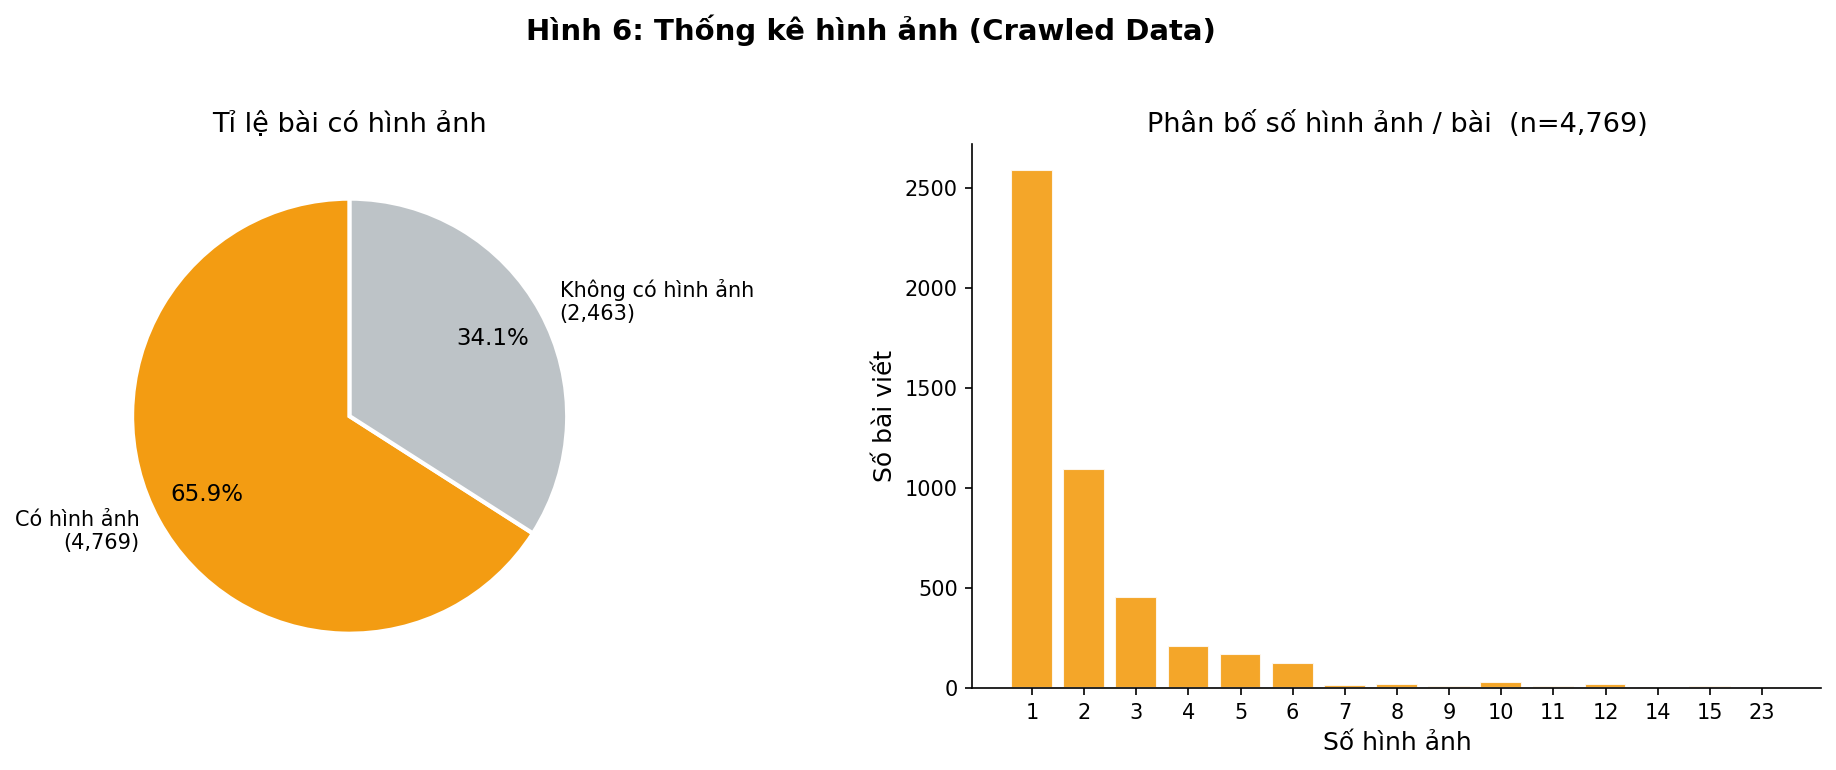

Saved: fig_c7_media.png

Trung bình ảnh/bài (bài có ảnh): 2.09
Tối đa ảnh/bài: 23


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie
has_i, no_i = df.has_images.sum(), (~df.has_images).sum()
axes[0].pie([has_i, no_i],
            labels=[f"Có hình ảnh\n({has_i:,})", f"Không có hình ảnh\n({no_i:,})"],
            colors=["#f39c12","#bdc3c7"], autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2), pctdistance=0.75)
axes[0].set_title("Tỉ lệ bài có hình ảnh")

# Image count distribution (articles with images)
df_img = df[df.image_count > 0]
img_vc = df_img.image_count.value_counts().sort_index().head(15)
axes[1].bar(img_vc.index.astype(str), img_vc.values,
            color="#f39c12", edgecolor="white", alpha=0.9)
axes[1].set_title(f"Phân bố số hình ảnh / bài  (n={len(df_img):,})")
axes[1].set_xlabel("Số hình ảnh")
axes[1].set_ylabel("Số bài viết")

plt.suptitle("Hình 6: Thống kê hình ảnh (Crawled Data)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_c7_media.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c7_media.png")
print(f"\nTrung bình ảnh/bài (bài có ảnh): {df_img.image_count.mean():.2f}")
print(f"Tối đa ảnh/bài: {df.image_count.max()}")

## 11. Hình ảnh theo nguồn tin

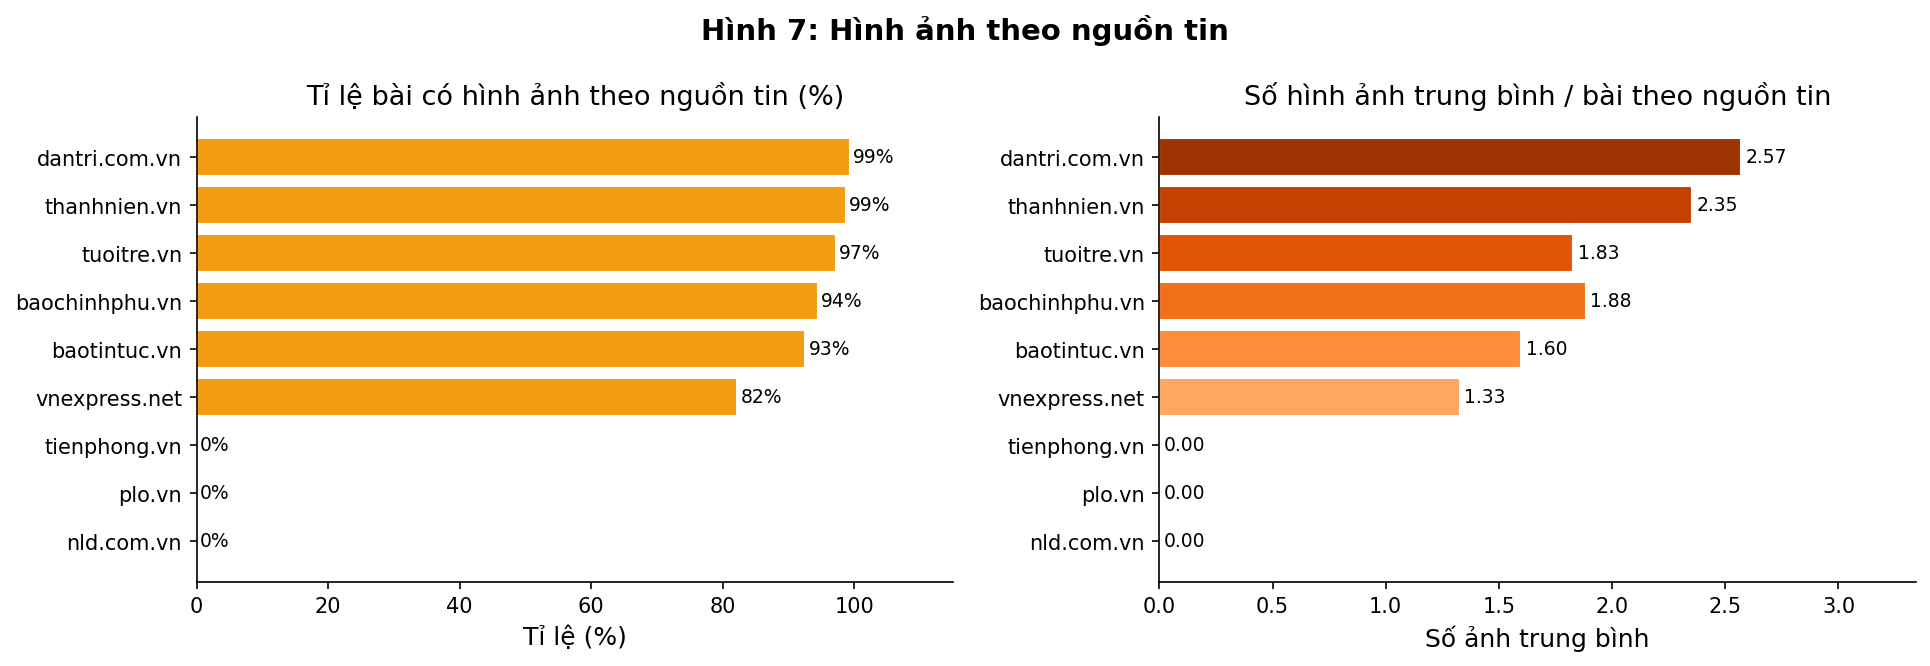

Saved: fig_c8_image_by_domain.png


In [13]:
img_by_dom = (
    df.groupby("domain")
    .agg(pct_img=("has_images","mean"), avg_img=("image_count","mean"))
    .mul({"pct_img":100, "avg_img":1})
    .sort_values("pct_img", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors_img = ["#e74c3c" if v < 50 else "#f39c12" for v in img_by_dom.pct_img]
axes[0].barh(img_by_dom.index, img_by_dom.pct_img, color=colors_img, edgecolor="white")
for i, v in enumerate(img_by_dom.pct_img):
    axes[0].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
axes[0].set_title("Tỉ lệ bài có hình ảnh theo nguồn tin (%)")
axes[0].set_xlabel("Tỉ lệ (%)")
axes[0].set_xlim(0, 115)

colors_avg = sns.color_palette("Oranges", len(img_by_dom))
axes[1].barh(img_by_dom.index, img_by_dom.avg_img, color=colors_avg, edgecolor="white")
for i, v in enumerate(img_by_dom.avg_img):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
axes[1].set_title("Số hình ảnh trung bình / bài theo nguồn tin")
axes[1].set_xlabel("Số ảnh trung bình")
axes[1].set_xlim(0, img_by_dom.avg_img.max() * 1.3)

plt.suptitle("Hình 7: Hình ảnh theo nguồn tin", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_c8_image_by_domain.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c8_image_by_domain.png")

## 12. Số lượng liên kết (Link Count)

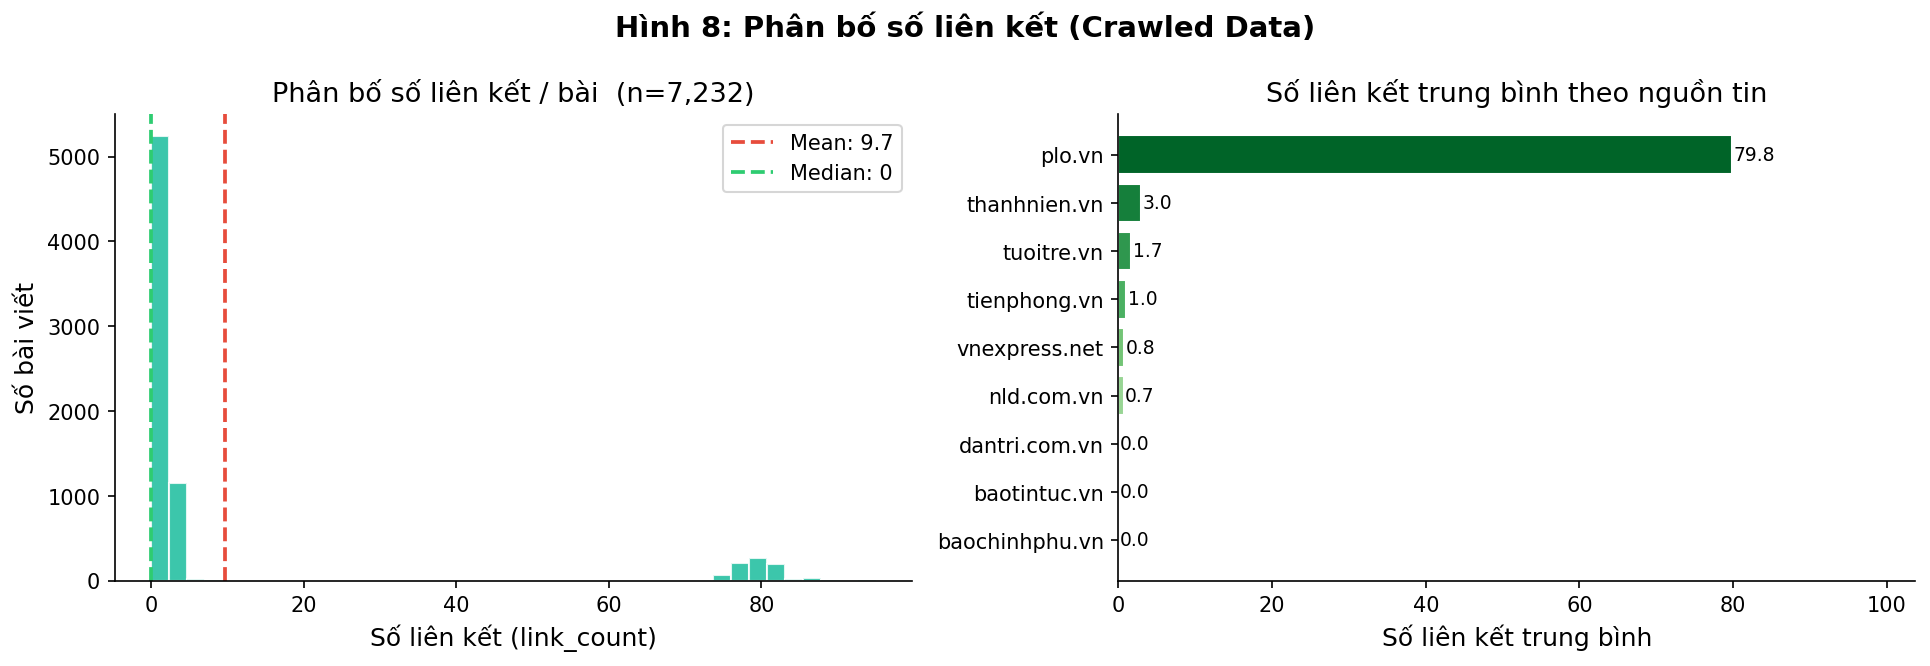

Saved: fig_c9_links.png

Bài có link_count > 0: 3,460 (47.8%)
link_count max: 95  |  mean: 9.66


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df.link_count, bins=40, color="#1abc9c", edgecolor="white", alpha=0.85)
axes[0].axvline(df.link_count.mean(),   color="#e74c3c", ls="--", lw=1.8,
                label=f"Mean: {df.link_count.mean():.1f}")
axes[0].axvline(df.link_count.median(), color="#2ecc71", ls="--", lw=1.8,
                label=f"Median: {df.link_count.median():.0f}")
axes[0].set_title(f"Phân bố số liên kết / bài  (n={len(df):,})")
axes[0].set_xlabel("Số liên kết (link_count)")
axes[0].set_ylabel("Số bài viết")
axes[0].legend()

avg_links = df.groupby("domain")["link_count"].mean().sort_values(ascending=True)
axes[1].barh(avg_links.index, avg_links.values,
             color=sns.color_palette("Greens", len(avg_links)), edgecolor="white")
for i, v in enumerate(avg_links.values):
    axes[1].text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)
axes[1].set_title("Số liên kết trung bình theo nguồn tin")
axes[1].set_xlabel("Số liên kết trung bình")
axes[1].set_xlim(0, avg_links.max() * 1.3)

plt.suptitle("Hình 8: Phân bố số liên kết (Crawled Data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_c9_links.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_c9_links.png")
print(f"\nBài có link_count > 0: {(df.link_count>0).sum():,} ({(df.link_count>0).mean()*100:.1f}%)")
print(f"link_count max: {df.link_count.max()}  |  mean: {df.link_count.mean():.2f}")

## 13. Bảng tổng hợp theo nguồn tin (Crawled Data)

In [15]:
summary = (
    df.groupby("domain")
    .agg(
        total       = ("id",         "count"),
        has_text_n  = ("has_text",   "sum"),
        has_title_n = ("has_title",  "sum"),
        has_img_n   = ("has_images", "sum"),
        avg_text    = ("text_length","mean"),
        avg_para    = ("paragraph_count","mean"),
        avg_img     = ("image_count","mean"),
        avg_link    = ("link_count","mean"),
    )
    .assign(
        pct_text  = lambda x: (x.has_text_n  / x.total * 100).round(1),
        pct_title = lambda x: (x.has_title_n / x.total * 100).round(1),
        pct_img   = lambda x: (x.has_img_n   / x.total * 100).round(1),
    )
    .sort_values("total", ascending=False)
)

cols_show = ["total","pct_text","pct_title","pct_img","avg_text","avg_para","avg_img","avg_link"]
display(
    summary[cols_show]
    .rename(columns={
        "total":"Tổng","pct_text":"Text (%)","pct_title":"Title (%)",
        "pct_img":"Ảnh (%)","avg_text":"Avg text len",
        "avg_para":"Avg đoạn","avg_img":"Avg ảnh","avg_link":"Avg links"
    })
    .round(1)
    .style
    .background_gradient(subset=["Text (%)","Title (%)","Ảnh (%)"], cmap="RdYlGn", vmin=0, vmax=100)
    .format({"Avg text len": "{:.0f}", "Avg đoạn": "{:.1f}", "Avg ảnh": "{:.2f}", "Avg links": "{:.1f}"})
    .set_caption("Bảng 4: Thống kê tổng hợp theo nguồn tin (từ crawled JSON)")
)

,Tổng,Text (%),Title (%),Ảnh (%),Avg text len,Avg đoạn,Avg ảnh,Avg links
domain,,,,,,,,
baochinhphu.vn,1222,100.000000,97.400000,94.400000,3636,13.8,1.90,0.0
thanhnien.vn,928,99.800000,100.000000,98.700000,2529,9.3,2.40,3.0
dantri.com.vn,864,0.000000,0.000000,99.300000,0,0.0,2.60,0.0
baotintuc.vn,807,0.000000,0.000000,92.600000,0,0.0,1.60,0.0
plo.vn,807,0.000000,0.000000,0.000000,0,0.0,0.00,79.8
nld.com.vn,804,0.000000,0.000000,0.000000,0,0.0,0.00,0.7
tuoitre.vn,703,0.000000,100.000000,97.200000,0,0.0,1.80,1.7
tienphong.vn,597,100.000000,100.000000,0.000000,2555,10.2,0.00,1.0
vnexpress.net,500,100.000000,100.000000,82.200000,2782,11.6,1.30,0.8


## 14. Timeline crawl

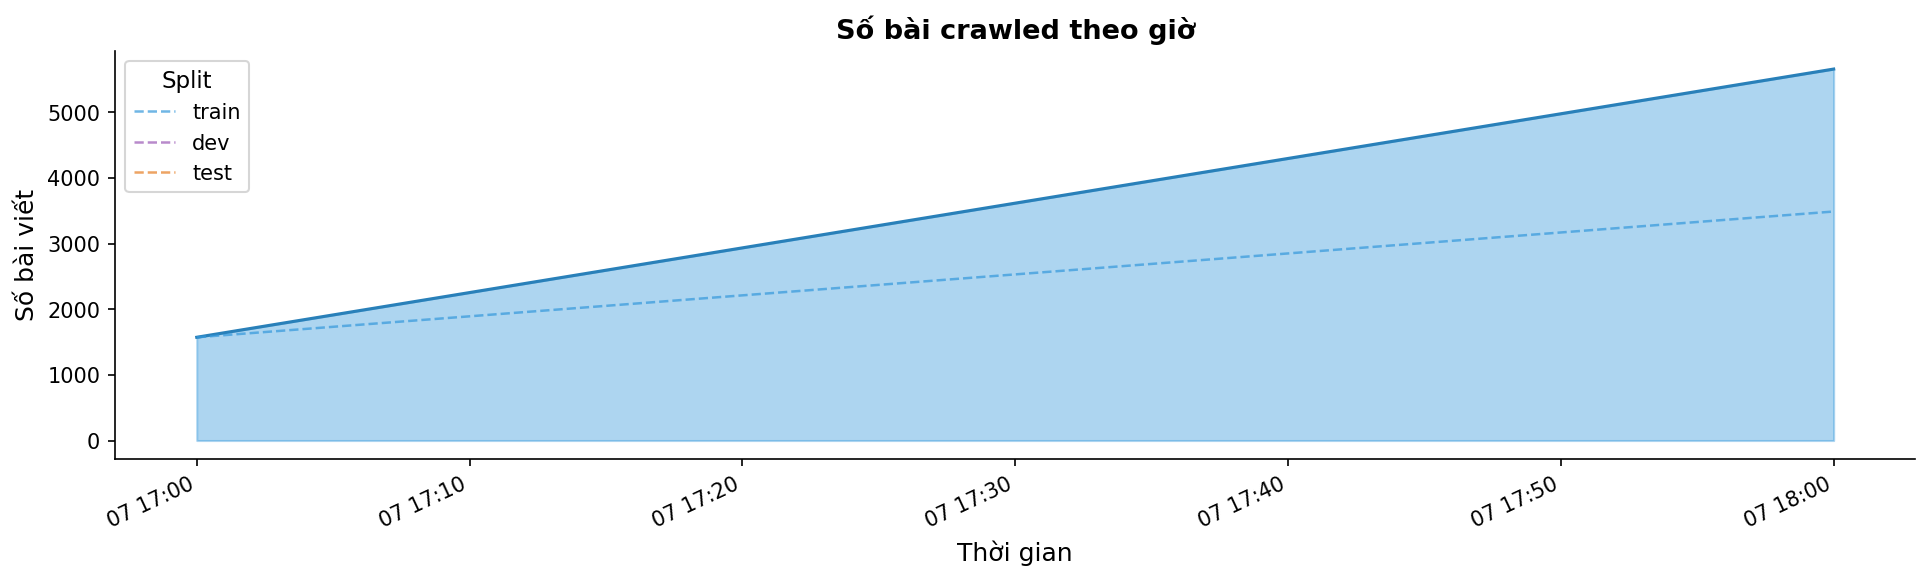

Saved: fig_c10_timeline.png
Bắt đầu : 2026-06-07 17:33:54.039716
Kết thúc: 2026-06-07 18:55:07.545500
Thời gian crawl: 0 days 01:21:13.505784


In [16]:
df["crawl_dt"] = pd.to_datetime(df["crawl_timestamp"], errors="coerce")
df["crawl_hour"] = df["crawl_dt"].dt.floor("h")

timeline = df.groupby("crawl_hour").size().reset_index(name="count").dropna(subset=["crawl_hour"])

if len(timeline) > 1:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(timeline.crawl_hour, timeline["count"], alpha=0.4, color="#3498db")
    ax.plot(timeline.crawl_hour, timeline["count"], color="#2980b9", linewidth=1.5)

    # Color by split
    for split, color in SPLIT_COLORS.items():
        sub = df[df.split == split].copy()
        sub["crawl_hour"] = sub["crawl_dt"].dt.floor("h")
        tl = sub.groupby("crawl_hour").size().reset_index(name="count").dropna()
        if len(tl):
            ax.plot(tl.crawl_hour, tl["count"], color=color, linewidth=1.2,
                    linestyle="--", alpha=0.7, label=split)

    ax.set_title("Số bài crawled theo giờ", fontweight="bold")
    ax.set_xlabel("Thời gian")
    ax.set_ylabel("Số bài viết")
    ax.legend(title="Split")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig("fig_c10_timeline.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("Saved: fig_c10_timeline.png")
    print(f"Bắt đầu : {df.crawl_dt.min()}")
    print(f"Kết thúc: {df.crawl_dt.max()}")
    crawl_duration = (df.crawl_dt.max() - df.crawl_dt.min())
    print(f"Thời gian crawl: {crawl_duration}")
else:
    print("Không đủ dữ liệu để vẽ timeline.")

---
## Tóm tắt — Crawled Data

| Hạng mục | Giá trị |
|---|---|
| Tổng bài viết | 7,232 |
| Train / Dev / Test | 5,062 / 723 / 1,447 |
| Nguồn tin (domain) | 9 báo điện tử |
| **Có văn bản** | ~3,245 bài (44.9%) |
| **Có tiêu đề** | ~3,918 bài (54.2%) |
| **Có hình ảnh** | ~4,769 bài (65.9%) |
| Avg text length | ~2,991 ký tự |
| Avg title length | ~60 ký tự |
| Avg đoạn văn | ~11.5 đoạn |

### Nguồn tin theo chất lượng crawl

| Nhóm | Nguồn tin |
|---|---|
| Text + Title + Ảnh ✅ | `baochinhphu.vn`, `thanhnien.vn` |
| Text + Title (không có ảnh) | `tienphong.vn` |
| Text + Ảnh (không có title) | `vnexpress.net` |
| Chỉ ảnh (không có text/title) | `dantri.com.vn`, `tuoitre.vn`, `baotintuc.vn` |
| Không có gì ❌ | `plo.vn`, `nld.com.vn` |

> **5/9 nguồn tin không extract được văn bản** — do JavaScript rendering, paywall, hoặc chặn bot.  
> Model multimodal cần tận dụng kết hợp **tiêu đề + hình ảnh + tuyên bố (Statement)** để bù đắp.